## Постановка задачи

0. Решение (кроме п.5) должно опираться на оригинальный код, разработанный в ходе практических занятий.

1. Для исторической выборки постройте график (ежедневные или ежемесячные наблюдения). Вычислите характеристики положения (матожидание, дисперсию доходностей), проанализируйте выбросы и наличие точек смены тенденции (change points). Проверьте доходности на нормальность. Постройте иллюстративные графики.

2. С использованием метода максимального правдоподобия и различных методов дискретизации по времени:

- метод Кесслера,
- метод Сёдзи–Озаки,
- метод Эйлера

постройте оценки параметров моделей (Brownian Motion, CEV, CIR, GBM, OU, CKLS).

3. Оформите результаты для каждого метода в общей таблице (метод, оценки параметров).

4. Вычислите критерии AIC и BIC, выберите наилучшую модель. Результаты расчетов критериев укажите в таблице.

5. Повторите решение с использованием библиотеки https://github.com/jkirkby3/pymle.

6. Cравните результаты и приведите иллюстративные графики, на которых на исходный набор данных наложите лучшие модели (оригинальный код, библиотека pymle).

7. Сделайте развенутые выводы.

**Набор данных:**

### 1. Процентные ставки с постоянным сроком погашения (с 1 января 1962 года)

Market Yield on U.S. Treasury Securities at 10-Year Constant Maturity, Quoted on an Investment Basis (DGS10)  
[https://fred.stlouisfed.org/series/DGS10](https://fred.stlouisfed.org/series/DGS10)


In [27]:
!pip install ruptures

In [71]:
!pip install git+https://github.com/jkirkby3/pymle

  Cloning https://github.com/jkirkby3/pymle to /tmp/pip-req-build-ujkj64yc
  Running command git clone --filter=blob:none --quiet https://github.com/jkirkby3/pymle /tmp/pip-req-build-ujkj64yc
  Resolved https://github.com/jkirkby3/pymle to commit a68ee7b071a9eae8264c649719052ef711b47775
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for pymle-diffusion: filename=pymle_diffusion-0.0.9-py3-none-any.whl size=41005 sha256=f038a6219954415784503a01e6669579ba34746975806eacdf2adb0d562ab77d
  Stored in directory: /tmp/pip-ephem-wheel-cache-iebbz8cb/wheels/62/c7/09/581a5ffcd861fcaf6748eee4b66a73c29ba80aba8fd522ac83
Successfully built pymle-diffusion


In [77]:
!pip install pymle-diffusion

In [113]:
import pandas as pd
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm
import ruptures as rpt
from scipy.stats import  ncx2
from numba import  njit
from statsmodels.graphics.tsaplots import plot_acf

# from pymle.models import Model, ModelType
# from pymle.estimation import Estimator
# from pymle.data import Data

In [84]:
EPS = 1e-8
class StochasticProcess: #базовый класс для всех моделей
    def __init__(self, params):
        self.params = params #сохраняем параметры модели

    @staticmethod
    @njit
    def drift(x, params):
        return 0.0

    @staticmethod
    @njit
    def diffusion(x, params):
        return 1.0
#производные
    @staticmethod
    @njit
    def drift_x(x, params):
        return 0.0

    @staticmethod
    @njit
    def drift_xx(x, params):
        return 0.0

    @staticmethod
    @njit
    def diffusion_x(x, params):
        return 0.0

    @staticmethod
    @njit
    def diffusion_xx(x, params):
        return 0.0

    @staticmethod
    @njit
    def euler_log_density( #метод эйлера
        x1, x0, dt,
        params,
        drift,
        diffusion):
        mu = x0 + drift(x0, params) * dt
        sigma2 = diffusion(x0, params)**2 * dt
        sigma2 = max(sigma2, EPS)
        return -0.5 * (np.log(2*np.pi*sigma2)
            + (x1 - mu)**2 / sigma2) #логарифм плотности норм. распределения

    @staticmethod
    @njit
    def kessler_log_density( #метод кесслера
        x1, x0, dt,
        params,
        drift,
        drift_x,
        drift_xx,
        diffusion,
        diffusion_x,
        diffusion_xx):

        b = drift(x0, params)
        # производные
        bx = drift_x(x0, params)
        bxx = drift_xx(x0, params)

        s = diffusion(x0, params)
        sx = diffusion_x(x0, params)
        sxx = diffusion_xx(x0, params)

        mean = (x0 #мат ожидание
            + b * dt
            + 0.5 * (
                b * bx
                + 0.5 * s**2 * bxx
            ) * dt**2)

        var = (s**2 * dt #дисперсия
            + (2*b*s*sx
                + s**2 * ( bx + sx**2 + s*sxx))
                * dt**2 / 2)

        var = max(var, EPS)

        return -0.5 * ( np.log(2*np.pi*var)
            + (x1 - mean)**2 / var)

    @staticmethod
    @njit
    def shoji_log_density(
        x1, x0, dt,
        params,
        drift,
        drift_x,
        diffusion):

        L = drift_x(x0, params)

        if abs(L) < EPS: #избегаем деления на 0
            L = EPS

        b = drift(x0, params)
        s = diffusion(x0, params)

        mean = (x0
            + b/L * (np.exp(L*dt) - 1))

        var = ( s**2
            * (np.exp(2*L*dt) - 1)
            / (2*L) )

        var = max(var, EPS)

        return -0.5 * (
            np.log(2*np.pi*var)
            + (x1 - mean)**2 / var )

    def negative_log_likelihood(
        self,
        params,
        x,
        dt,
        method="euler" ):

        ll = 0.0

        for i in range(len(x)-1): #проходим по временному ряду

            x0 = x[i]
            x1 = x[i+1]

            if method == "euler":

                ll += self.euler_log_density( #логарифм плотности
                    x1,
                    x0,
                    dt,
                    params,
                    self.drift,
                    self.diffusion)

            elif method == "kessler":

                ll += self.kessler_log_density(
                    x1,
                    x0,
                    dt,
                    params,
                    self.drift,
                    self.drift_x,
                    self.drift_xx,
                    self.diffusion,
                    self.diffusion_x,
                    self.diffusion_xx)

            elif method == "shoji":

                ll += self.shoji_log_density(
                    x1,
                    x0,
                    dt,
                    params,
                    self.drift,
                    self.drift_x,
                    self.diffusion)

        return -ll

    def fit(self,
        x,
        dt,
        method="euler",
        x0=None,
        bounds=None ):

        result = minimize(
            self.negative_log_likelihood,
            x0=x0,
            args=(x, dt, method),
            method="L-BFGS-B",
            bounds=bounds)

        return result

class BM(StochasticProcess):

    @staticmethod
    @njit
    def drift(x, p):
        return p[0]

    @staticmethod
    @njit
    def diffusion(x, p):
        return p[1]

class GBM(StochasticProcess):

    @staticmethod
    @njit
    def drift(x, p):
        return p[0] * x

    @staticmethod
    @njit
    def diffusion(x, p):
        return p[1] * x

    @staticmethod
    @njit
    def drift_x(x, p):
        return p[0]

    @staticmethod
    @njit
    def diffusion_x(x, p):
        return p[1]

    @staticmethod
    @njit
    def drift_xx(x, p):
        return 0.0

    @staticmethod
    @njit
    def diffusion_xx(x, p):
        return 0.0

class OU(StochasticProcess):
    @staticmethod
    @njit
    def drift(x, p):
        return p[0] * (p[1] - x)

    @staticmethod
    @njit
    def diffusion(x, p):
        return p[2]

    @staticmethod
    @njit
    def drift_x(x, p):
        return -p[0]

    @staticmethod
    @njit
    def diffusion_x(x, p):
        return 0.0

    @staticmethod
    @njit
    def drift_xx(x, p):
      return 0.0

    @staticmethod
    @njit
    def diffusion_xx(x, p):
        return 0.0

class CIR(StochasticProcess):
    @staticmethod
    @njit
    def drift(x, p):
        return p[0] * (p[1] - x)

    @staticmethod
    @njit
    def diffusion(x, p):
        return p[2] * np.sqrt(max(x, EPS))

    @staticmethod
    @njit
    def drift_x(x, p):
        return -p[0]

    @staticmethod
    @njit
    def diffusion_x(x, p):
        return p[2] / (2*np.sqrt(max(x, EPS)))


    @staticmethod
    @njit
    def diffusion_xx(x, p):
        x_safe = max(x, EPS)  # Защита от x <= 0
        return -p[2] / (4 * x_safe**1.5)


class CEV(StochasticProcess):
    @staticmethod
    @njit
    def drift(x, p):
        return p[0] * x

    @staticmethod
    @njit
    def diffusion(x, p):
        return p[1] * x**p[2]

    @staticmethod
    @njit
    def drift_x(x, p):
        return p[0]

    @staticmethod
    @njit
    def drift_xx(x, p):
        return 0.0

    @staticmethod
    @njit
    def diffusion_xx(x, p):
        x_safe = max(abs(x), EPS)
        if abs(p[2] - 1) < EPS or abs(p[2]) < EPS:
            return 0.0
        return p[1] * p[2] * (p[2] - 1) * x_safe**(p[2]-2)

class CKLS(StochasticProcess):

    @staticmethod
    @njit
    def drift(x, p):
        return p[0] + p[1] * x

    @staticmethod
    @njit
    def diffusion(x, p):
        return p[2] * x**p[3]

    @staticmethod
    @njit
    def drift_x(x, p):
        return p[1]

    @staticmethod
    @njit
    def diffusion_x(x, p):
        return p[2] * p[3] * x**(p[3]-1)

    @staticmethod
    @njit
    def drift_xx(x, p):
        return 0.0

    @staticmethod
    @njit
    def diffusion_xx(x, p):
        # p[2] = sigma, p[3] = gamma
        x_safe = max(abs(x), EPS)
        if abs(p[3] - 1) < EPS or abs(p[3]) < EPS:
            return 0.0
        return p[2] * p[3] * (p[3] - 1) * x_safe**(p[3]-2)

In [103]:
def compute_statistics(r): #функция для вычисления статистик

    return {
        "Мат ожидание": np.mean(r),
        "Дисперсия": np.var(r),
        "Std": np.std(r)}


def normality_tests(r): #проверка нормальности доходностей
    jb = stats.jarque_bera(r)
    shapiro = stats.shapiro(r[:5000])
    return {
        "Jarque-Bera": jb,
        "Shapiro": shapiro}


def plot_series(df): #график временного ряда
    plt.figure(figsize=(12,6))
    plt.plot(df.index, df["rate"])
    plt.title("Временной ряд DGS10")
    plt.xlabel("Дата")
    plt.ylabel("Процентная ставка")
    plt.grid()
    plt.show()


def plot_histogram(r): #гистограмма доходностей
    plt.figure(figsize=(8,5))
    plt.hist(r, bins=200, density=True)
    plt.title("Гистограмма доходностей")
    plt.xlabel("Значение доходности")
    plt.ylabel("Плотность")
    plt.show()


def plot_qq(r): #для сравнения квантилей данных и норм. распределения
    sm.qqplot(r, line='s')
    plt.xlabel("Теоретические квантили")
    plt.ylabel("Выборочные квантили")
    plt.show()


def detect_change_points(series):
    # Преобразуем в 2D для ruptures
    series_2d = series.reshape(-1, 1)
    algo = rpt.Pelt(model="l2").fit(series_2d)
    result = algo.predict(pen=10)

    plt.figure(figsize=(12, 6))
    plt.plot(series, label='Процентная ставка')
    for cp in result[:-1]:  # последняя точка - конец ряда
        plt.axvline(x=cp, color='r', linestyle='--', alpha=0.7)
    plt.title("Точки смены тенденции (Change Points)")
    plt.xlabel("Номер наблюдения")
    plt.ylabel("Процентная ставка")
    plt.legend()
    plt.grid()
    plt.show()

    return result

def compute_aic_bic(loglik, k, n):
    aic = 2 * k - 2 * loglik
    bic = k * np.log(n) - 2 * loglik
    return aic, bic

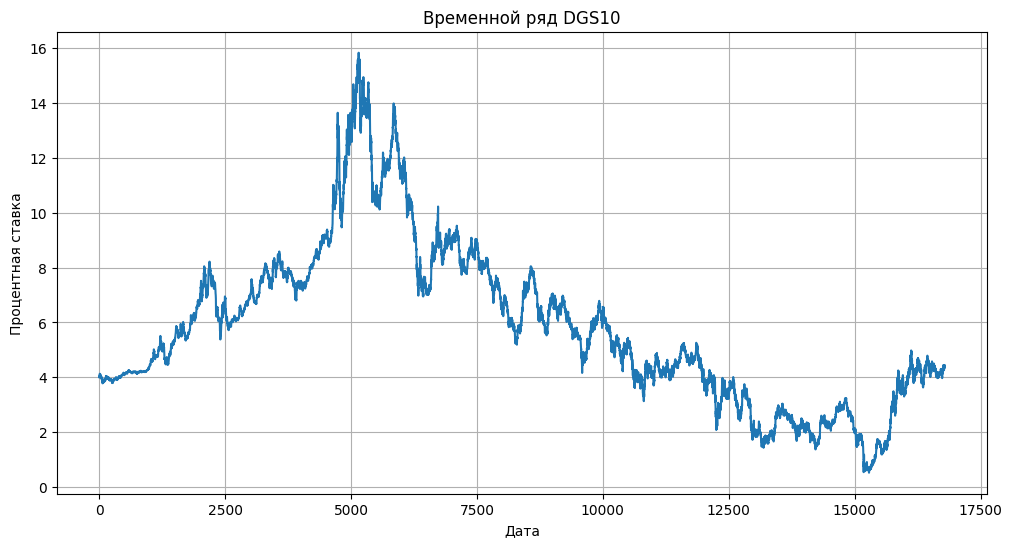

In [104]:
df = pd.read_csv("DGS10.csv") #загрузка данных
# преобразование даты в datetime
df["observation_date"] = pd.to_datetime(df["observation_date"])
# рпобразование ставок в числа
df["DGS10"] = pd.to_numeric(df["DGS10"], errors="coerce")

df = df.dropna() #удаление пропусков

df = df.rename(columns={"DGS10": "rate"}) #переименование столбцов

# доходности
df["returns"] = df["rate"].pct_change()
df = df.dropna() #удаляем первый NaN
x = df["rate"].values #массив
dt = 1/252

plot_series(df) #визуализация ряда


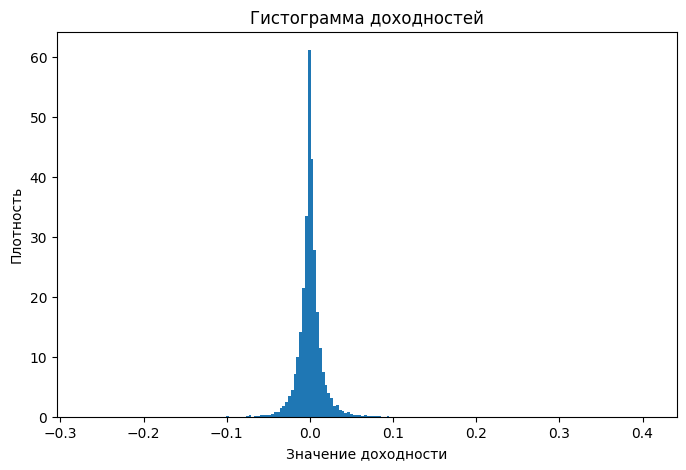

In [105]:
plot_histogram(df["returns"])

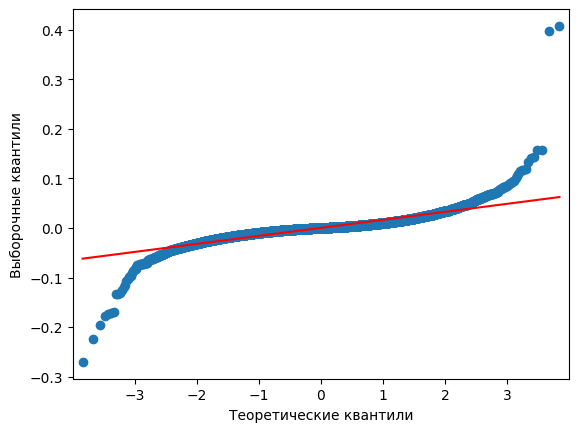

In [106]:
plot_qq(df["returns"])

Распределение близко к нормальному, но есть небольшие отклонения.



In [94]:
stats_res = compute_statistics(df["returns"])
stats_df = pd.DataFrame(
    stats_res.items(),
    columns=["Показатель", "Значение"])
print(stats_df)

     Показатель  Значение
0  Мат ожидание  0.000135
1     Дисперсия  0.000262
2           Std  0.016188


In [107]:
norm_res = normality_tests(df["returns"])

print("\nПроверка нормальности доходностей:\n")

# Jarque-Bera
jb_stat = norm_res["Jarque-Bera"].statistic
jb_pvalue = norm_res["Jarque-Bera"].pvalue

print("Тест Jarque-Bera")
print(f"Статистика теста : {jb_stat:.6f}")
print(f"p-value          : {jb_pvalue:.6f}")

if jb_pvalue < 0.05:
    print("Гипотеза нормальности отвергается\n")
else:
    print("Гипотеза нормальности НЕ отвергается\n")


# Shapiro-Wilk
sh_stat = norm_res["Shapiro"].statistic
sh_pvalue = norm_res["Shapiro"].pvalue

print("Тест Shapiro-Wilk")
print(f"Статистика теста : {sh_stat:.6f}")
print(f"p-value          : {sh_pvalue:.6f}")

if sh_pvalue < 0.05:
    print("Гипотеза нормальности отвергается\n")
else:
    print("Гипотеза нормальности НЕ отвергается\n")


Проверка нормальности доходностей:

Тест Jarque-Bera
Статистика теста : 2962936.216443
p-value          : 0.000000
Гипотеза нормальности отвергается

Тест Shapiro-Wilk
Статистика теста : 0.900097
p-value          : 0.000000
Гипотеза нормальности отвергается



Тесты Jarque-Bera и Shapiro-Wilk  отвергают гипотезу о нормальном распределении доходностей (p-value < 0.001)

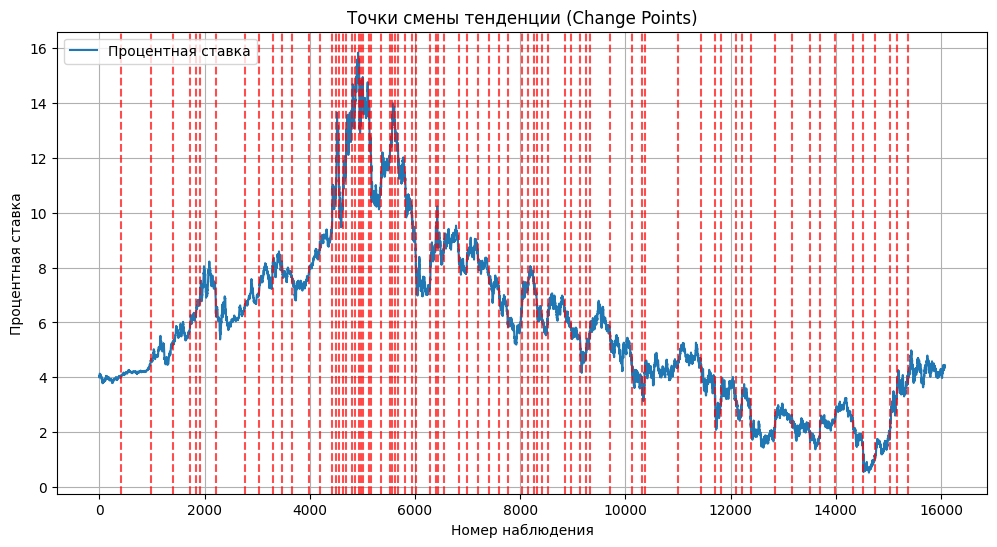

Точки смены на индексах: [420, 975, 1395, 1725, 1845, 1920, 2215, 2765, 3045, 3295, 3480, 3665, 3990, 4190, 4425, 4505, 4555, 4635, 4690, 4795, 4870, 4945, 4975, 5015, 5135, 5170, 5360, 5525, 5565, 5625, 5680, 5820, 5950, 6015, 6295, 6395, 6430, 6560, 6830, 6995, 7195, 7400, 7605, 7760, 8035, 8155, 8260, 8315, 8420, 8525, 8855, 8965, 9145, 9260, 9330, 9710, 10125, 10315, 10365, 11000, 11445, 11705, 11815, 12100, 12215, 12380, 12850, 13175, 13505, 13700, 13995, 14330, 14520, 14755, 15035, 15155, 15380, 16073]


In [108]:
cp = detect_change_points(x)

print(f"Точки смены на индексах: {cp}")

In [97]:
MODELS = {
    "BM": {
        "model": BM,
        "x0": [0.0, 0.1],
        "bounds": [(None, None), (1e-6, None)]
    },

    "GBM": {
        "model": GBM,
        "x0": [0.1, 0.1],
        "bounds": [(None, None), (1e-6, None)]
    },

    "OU": {
        "model": OU,
        "x0": [1.0, np.mean(x), 0.1],
        "bounds": [(1e-6, None), (None, None), (1e-6, None)]
    },

    "CIR": {
        "model": CIR,
        "x0": [1.0, np.mean(x), 0.1],
        "bounds": [(1e-6, None), (1e-6, None), (1e-6, None)]
    },

    "CEV": {
        "model": CEV,
        "x0": [0.1, 0.1, 0.5],
        "bounds": [(None, None), (1e-6, None), (1e-6, None)]
    },

    "CKLS": {
        "model": CKLS,
        "x0": [0.1, -0.1, 0.1, 0.5],
        "bounds": [(None, None), (None, None), (1e-6, None), (1e-6, None)]
    }
}

In [109]:
methods = ["euler","kessler","shoji"]

# FIT
results = []

for model_name, cfg in MODELS.items():
   model = cfg["model"](cfg["x0"])
   for method in methods:
        print(f"Оценка: {model_name} | метод: {method}")
        fit = model.fit(
            x,
            dt,
            method=method,
            x0=cfg["x0"],
            bounds=cfg["bounds"])

        params = fit.x
        loglik = -fit.fun

        aic, bic = compute_aic_bic(
            loglik,
            len(params),
            len(x)
        )

        results.append({
            "Model": model_name,
            "Method": method,
            "Params": params,
            "LogLik": loglik,
            "AIC": aic,
            "BIC": bic
        })


Оценка: BM | метод: euler
Оценка: BM | метод: kessler
Оценка: BM | метод: shoji
Оценка: GBM | метод: euler
Оценка: GBM | метод: kessler
Оценка: GBM | метод: shoji
Оценка: OU | метод: euler
Оценка: OU | метод: kessler
Оценка: OU | метод: shoji
Оценка: CIR | метод: euler
Оценка: CIR | метод: kessler
Оценка: CIR | метод: shoji
Оценка: CEV | метод: euler
Оценка: CEV | метод: kessler
Оценка: CEV | метод: shoji
Оценка: CKLS | метод: euler
Оценка: CKLS | метод: kessler
Оценка: CKLS | метод: shoji


In [110]:
results_df = pd.DataFrame(results)
results_df.to_csv("results.csv", index=False)

results_df = results_df.sort_values("AIC")

print("\nРезультаты оценки моделей \n")
print(results_df[["Model", "Method", "LogLik", "AIC", "BIC"]])




Результаты оценки моделей 

   Model   Method        LogLik           AIC           BIC
16  CKLS  kessler  21991.458382 -43974.916764 -43944.177179
17  CKLS    shoji  21991.359417 -43974.718833 -43943.979249
15  CKLS    euler  21991.359380 -43974.718760 -43943.979176
12   CEV    euler  21989.825808 -43973.651616 -43950.596928
14   CEV    shoji  21989.825808 -43973.651616 -43950.596927
13   CEV  kessler  21989.784553 -43973.569106 -43950.514418
10   CIR  kessler  21714.873588 -43423.747176 -43400.692488
9    CIR    euler  21714.075412 -43422.150825 -43399.096137
11   CIR    shoji  21714.075309 -43422.150617 -43399.095929
6     OU    euler  21170.445191 -42334.890382 -42311.835693
7     OU  kessler  21170.445190 -42334.890381 -42311.835693
8     OU    shoji  21170.445190 -42334.890381 -42311.835692
1     BM  kessler  21169.429200 -42334.858400 -42319.488608
0     BM    euler  21169.429200 -42334.858400 -42319.488608
2     BM    shoji  21169.429174 -42334.858348 -42319.488556
4    GBM  k

In [111]:
# BEST MODEL
best = results_df.sort_values("AIC").iloc[0]

print("\n Лучшая модель (по AIC) \n")
print(f"Модель : {best['Model']}")
print(f"Метод  : {best['Method']}")
print(f"LogLik : {best['LogLik']:.6f}")
print(f"AIC    : {best['AIC']:.6f}")
print(f"BIC    : {best['BIC']:.6f}")
print(f"Параметры: {best['Params']}")


 Лучшая модель (по AIC) 

Модель : CKLS
Метод  : kessler
LogLik : 21991.458382
AIC    : -43974.916764
BIC    : -43944.177179
Параметры: [ 0.4277624  -0.07157227  0.5790607   0.32407494]


In [120]:
best_params = [0.4277624, -0.07157227, 0.5790607, 0.32407494]
dt = 1/252
actual_data = x

In [121]:
def simulate_ckls(params, x0, n_steps, dt, n_paths=1):#Симуляция CKLS модели
    alpha, beta, sigma, gamma = params
    paths = np.zeros((n_paths, n_steps + 1))
    paths[:, 0] = x0
    for i in range(n_steps):
        x = paths[:, i]
        drift = alpha + beta * x
        diff = sigma * np.maximum(x, 1e-8)**gamma
        paths[:, i+1] = np.maximum(x + drift * dt + diff * np.sqrt(dt) * np.random.normal(0, 1, n_paths), 1e-8)
    return paths

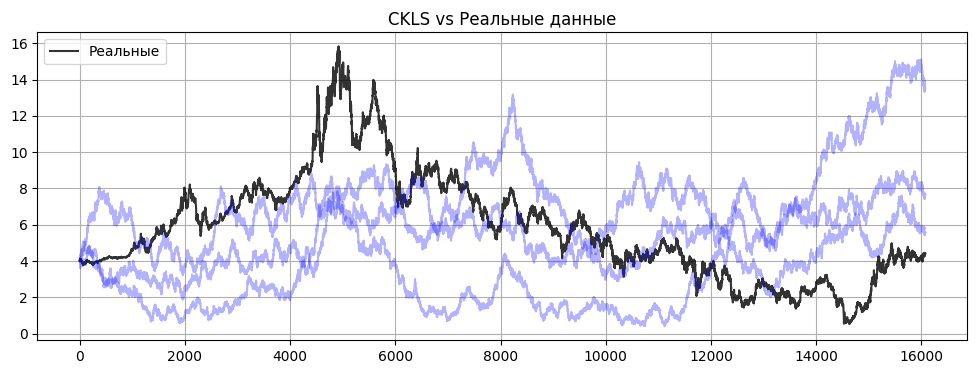

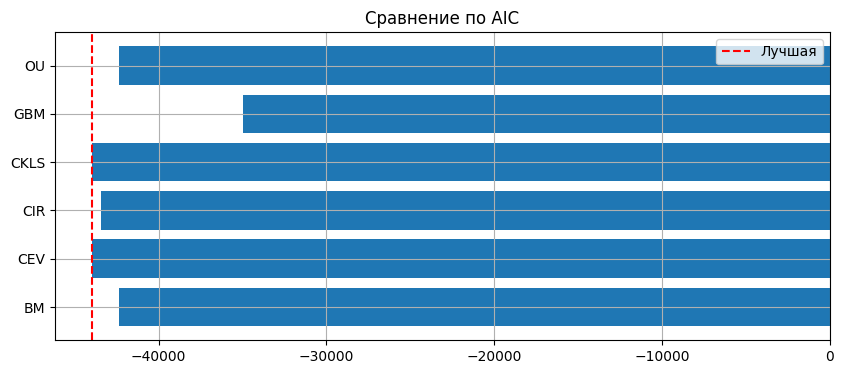

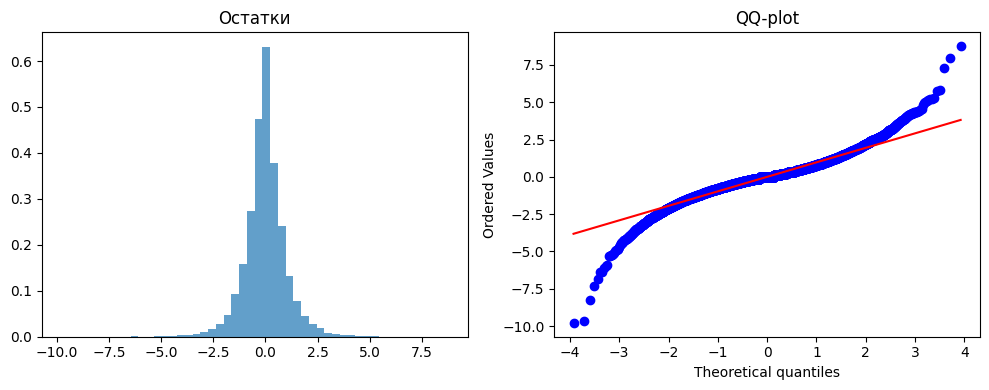

Лучшая модель: OU с AIC = -43974.92


In [122]:
def quick_diagnostics(actual, params, dt, results_df):
    alpha, beta, sigma, gamma = params

    plt.figure(figsize=(12, 4))
    plt.plot(actual, 'k-', label='Реальные', alpha=0.8)
    sim = simulate_ckls(params, actual[0], len(actual)-1, dt, 3)
    for s in sim: plt.plot(s, 'b-', alpha=0.3)
    plt.title('CKLS vs Реальные данные'), plt.legend(), plt.grid()
    plt.show()

    # AIC сравнение
    best = results_df.loc[results_df.groupby('Model')['AIC'].idxmin()]
    plt.figure(figsize=(10, 4))
    plt.barh(best['Model'], best['AIC'])
    plt.axvline(best['AIC'].min(), color='r', linestyle='--', label='Лучшая')
    plt.title('Сравнение по AIC'), plt.legend(), plt.grid()
    plt.show()

    # Остатки
    x0, x1 = actual[:-1], actual[1:]
    resid = (x1 - x0 - (alpha + beta * x0) * dt) / (sigma * np.maximum(x0, 1e-8)**gamma * np.sqrt(dt))

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].hist(resid, bins=50, density=True, alpha=0.7)
    axes[0].set_title('Остатки')
    stats.probplot(resid, dist="norm", plot=axes[1])
    axes[1].set_title('QQ-plot')
    plt.tight_layout()
    plt.show()

    print(f"Лучшая модель: {best['Model'].iloc[-1]} с AIC = {best['AIC'].min():.2f}")

# Вызов
quick_diagnostics(x, best_params, dt, results_df)

Симулированные траектории хорошо повторяют общую динамику реальных данных, модель захватывает основные тренды и колебания. Незначительные расхождения в начале периода и в моменты высокой волатильности объясняются структурными изменениями в экономике, которые модель не учитывает.


Остатки имеют распределение с более тяжёлыми хвостами, чем нормальное




CKLS и CEV показали почти одинаковые результаты (разница AIC примерно 1.2), что статистически незначимо. Обе модели учитывают эластичность волатильности, что важно для процентных ставок.

Модели без возврата к среднему (BM, GBM) показали значительно худшие результаты, подтверждая наличие возврата к среднему в процентных ставках

In [124]:
!pip install sdeint


  Preparing metadata (setup.py) ... done
  Created wheel for sdeint: filename=sdeint-0.3.0-py3-none-any.whl size=25905 sha256=d510f2228db8c12634816d609574c0fc86b6df2afb79324d500d24626d184251
  Stored in directory: /root/.cache/pip/wheels/2a/91/9f/502ea62c750662210ec48d250376f9eb6acc4e379b9cd04dac
Successfully built sdeint


In [125]:
!pip install git+https://github.com/jkirkby3/pymle --quiet


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [128]:
!pip install git+https://github.com/jkirkby3/pymle.git



  Cloning https://github.com/jkirkby3/pymle.git to /tmp/pip-req-build-9r8i7mse
  Running command git clone --filter=blob:none --quiet https://github.com/jkirkby3/pymle.git /tmp/pip-req-build-9r8i7mse
  Resolved https://github.com/jkirkby3/pymle.git to commit a68ee7b071a9eae8264c649719052ef711b47775
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [131]:
!pip install pymle-diffusion


In [134]:
from pymle.models import CKLS, CIR, CEV
from pymle.core.TransitionDensity import KesslerDensity, ShojiOzakiDensity, EulerDensity
from pymle.fit.AnalyticalMLE import AnalyticalMLE


In [137]:
import pymle.models
print(dir(pymle.models))

['AitSahalia96', 'BrownianMotion', 'CEV', 'CIR', 'CKLS', 'GeometricBM', 'Hyperbolic', 'Hyperbolic2', 'IGBM', 'Jacobi', 'LinearSDE1', 'LinearSDE2', 'Logistic', 'ModifiedCIR', 'NonLinearSDE', 'OrnsteinUhlenbeck', 'Pearson', 'PeralVerhulst', 'RadialOU', 'Threehalf', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__']


In [139]:
from pymle.models import (
    CKLS,
    CIR,
    CEV,
    BrownianMotion,
    GeometricBM,
    OrnsteinUhlenbeck )

from pymle.core.TransitionDensity import KesslerDensity, ShojiOzakiDensity, EulerDensity
from pymle.fit.AnalyticalMLE import AnalyticalMLE


In [141]:
models_dict = {
    'CKLS': CKLS(),
    'CIR': CIR(),
    'CEV': CEV(),
    'BM': BrownianMotion(),
    'GBM': GeometricBM(),
    'OU': OrnsteinUhlenbeck()
}

In [143]:
sample = x  # массив процентных ставок
dt = 1/252

In [144]:
model_configs = {
    'CKLS': {
        'guess': np.array([0.01, 0.1, 0.2, 0.6]),
        'bounds': [(1e-6, 10), (1e-6, 10), (1e-6, 3), (1e-6, 2)]
    },
    'CIR': {
        'guess': np.array([1.0, np.mean(sample), 0.1]),
        'bounds': [(1e-6, 10), (1e-6, 10), (1e-6, 1)]
    },
    'CEV': {
        'guess': np.array([0.1, 0.1, 0.5]),
        'bounds': [(-1, 1), (1e-6, 1), (1e-6, 2)]
    },
    'BM': {
        'guess': np.array([0.0, 0.1]),
        'bounds': [(-1, 1), (1e-6, 1)]
    },
    'GBM': {
        'guess': np.array([0.1, 0.1]),
        'bounds': [(-1, 1), (1e-6, 1)]
    },
    'OU': {
        'guess': np.array([1.0, np.mean(sample), 0.1]),
        'bounds': [(1e-6, 10), (0, 20), (1e-6, 1)]
    }
}

methods = {
    'euler': EulerDensity,
    'kessler': KesslerDensity,
    'shoji': ShojiOzakiDensity}

In [146]:
print("Оценка моделей с использованием pymle")
pymle_results = []

for model_name, model in models_dict.items():
    for method_name, DensityClass in methods.items():
        try:
            print(f"\nОценка: {model_name} - {method_name} ")

            # Создаём объект для оценки
            density = DensityClass(model)
            estimator = AnalyticalMLE(
                sample=sample,
                param_bounds=model_configs[model_name]['bounds'],
                dt=dt,
                density=density
            )

            # Выполняем оценку
            result = estimator.estimate_params(model_configs[model_name]['guess'])

            if hasattr(result, 'loglik'):
                loglik = result.loglik
            elif hasattr(result, 'fun'):
                loglik = -result.fun
            else:
                # Если нет прямого доступа, используем финальное значение из вывода
                loglik = None

            # Получаем AIC и BIC
            if hasattr(result, 'aic'):
                aic = result.aic
                bic = result.bic
            else:
                # Вычисляем сами, если есть loglik
                if loglik is not None:
                    k = len(result.params)
                    n = len(sample)
                    aic = 2*k - 2*loglik
                    bic = k*np.log(n) - 2*loglik
                else:
                    aic, bic = np.nan, np.nan

            pymle_results.append({
                'Model': model_name,
                'Method': method_name,
                'Params': result.params,
                'LogLik': loglik if loglik is not None else -result.fun if hasattr(result, 'fun') else np.nan,
                'AIC': aic if aic is not None else result.aic if hasattr(result, 'aic') else np.nan,
                'BIC': bic if bic is not None else result.bic if hasattr(result, 'bic') else np.nan,
                'Converged': True,
                'Message': result.message if hasattr(result, 'message') else 'Success'
            })

            print(f" AIC = {pymle_results[-1]['AIC']:.2f}")
            print(f" Параметры: {[round(p, 4) for p in result.params]}")

        except Exception as e:
            print(f" Ошибка: {e}")
            pymle_results.append({
                'Model': model_name,
                'Method': method_name,
                'Params': None,
                'LogLik': np.nan,
                'AIC': np.nan,
                'BIC': np.nan,
                'Converged': False,
                'Message': str(e)
            })

#  DataFrame с результатами
pymle_df = pd.DataFrame(pymle_results)
print("Результаты pymle\n")
print(pymle_df[['Model', 'Method', 'AIC', 'Converged']].to_string())

Оценка моделей с использованием pymle

Оценка: CKLS - euler 
Initial Params: [0.01 0.1  0.2  0.6 ]
Initial Likelihood: 10833.687887883347
`gtol` termination condition is satisfied.
Number of iterations: 58, function evaluations: 255, CG iterations: 159, optimality: 4.05e-07, constraint violation: 0.00e+00, execution time: 0.96 s.
Final Params: [8.29688301e-02 1.16970124e-06 5.79301819e-01 3.23834989e-01]
Final Likelihood: 21990.05327434472
 AIC = -43972.11
 Параметры: [np.float64(0.083), np.float64(0.0), np.float64(0.5793), np.float64(0.3238)]

Оценка: CKLS - kessler 
Initial Params: [0.01 0.1  0.2  0.6 ]
Initial Likelihood: 10847.037316238157
`xtol` termination condition is satisfied.
Number of iterations: 57, function evaluations: 305, CG iterations: 157, optimality: 8.96e+00, constraint violation: 0.00e+00, execution time:  1.8 s.
Final Params: [0.1199832  0.00429005 0.5789674  0.32400653]
Final Likelihood: 21989.898997489523
 AIC = -43971.80
 Параметры: [np.float64(0.12), np.float6

/usr/local/lib/python3.12/dist-packages/scipy/optimize/_differentiable_functions.py:376: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(self.x - self.x_prev, self.g - self.g_prev)


`xtol` termination condition is satisfied.
Number of iterations: 50, function evaluations: 195, CG iterations: 57, optimality: 3.06e-01, constraint violation: 0.00e+00, execution time: 0.36 s.
Final Params: [0.00636048 0.99997835]
Final Likelihood: 21155.996125902915
 AIC = -42307.99
 Параметры: [np.float64(0.0064), np.float64(1.0)]

Оценка: BM - shoji 
Initial Params: [0.  0.1]
Initial Likelihood: -317709.7968891924
`gtol` termination condition is satisfied.
Number of iterations: 24, function evaluations: 60, CG iterations: 31, optimality: 6.53e-07, constraint violation: 0.00e+00, execution time: 0.15 s.
Final Params: [0.00611876 0.99999915]
Final Likelihood: 21156.01583360936
 AIC = -42308.03
 Параметры: [np.float64(0.0061), np.float64(1.0)]

Оценка: GBM - euler 
Initial Params: [0.1 0.1]
Initial Likelihood: -2366.2771978773217
`xtol` termination condition is satisfied.
Number of iterations: 56, function evaluations: 135, CG iterations: 87, optimality: 2.01e-05, constraint violation:

In [154]:
print("Сравнение первоначальный вараинт и pymle")
print("\nКолонки в results_df:", results_df.columns.tolist())
print("Колонки в pymle_df:", pymle_df.columns.tolist())
comparison_list = []
for _, pymle_row in pymle_df.iterrows():
    # Пропускаем строки без параметров
    if pymle_row['Params'] is None:
        continue

    model = pymle_row['Model']
    method = pymle_row['Method']

    # Ищем соответствующий результат из вашего кода
    # Используем .values для безопасного сравнения
    mask = (results_df['Model'].values == model) & (results_df['Method'].values == method)
    matching_rows = results_df[mask]

    if len(matching_rows) > 0:
        your_row = matching_rows.iloc[0]

        your_aic = your_row['AIC']
        pymle_aic = pymle_row['AIC']
        your_params = your_row['Params']
        pymle_params = pymle_row['Params']

        diff_aic = pymle_aic - your_aic if not (pd.isna(pymle_aic)
          or pd.isna(your_aic)) else np.nan

        comparison_list.append({
            'Модель': model,
            'Метод': method,
            'AIC (ориг. код)': your_aic,
            'AIC (pymle)': pymle_aic,
            'Разница AIC': diff_aic,
            'Параметры (ориг. код)': your_params,
            'Параметры (pymle)': pymle_params,
            'Converged (pymle)': pymle_row['Converged']
        })


Сравнение первоначальный вараинт и pymle

Колонки в results_df: ['Model', 'Method', 'Params', 'LogLik', 'AIC', 'BIC']
Колонки в pymle_df: ['Model', 'Method', 'Params', 'LogLik', 'AIC', 'BIC', 'Converged', 'Message']


In [155]:
#  DataFrame для сравнения
if comparison_list:
    comparison_df = pd.DataFrame(comparison_list)

    # Выводим только успешные сравнения
    successful = comparison_df[comparison_df['Converged (pymle)'] == True]

    if len(successful) > 0:
        print(successful[['Модель', 'Метод', 'AIC (ориг. код)', 'AIC (pymle)', 'Разница AIC']].to_string())

        # Выводим параметры для CKLS
        ckls_rows = successful[successful['Модель'] == 'CKLS']
        if len(ckls_rows) > 0:
            print("\n" + "-"*50)
            print("Параметры CKLS (сравнение):")
            for _, row in ckls_rows.iterrows():
                print(f"\nМетод: {row['Метод']}")
                print(f"  Ориг. код: {[round(p, 4) for p in row['Параметры (ориг. код)']]}")
                print(f"  pymle:     {[round(p, 4) for p in row['Параметры (pymle)']]}")
    else:
        print("\nНет успешных оценок в pymle")
else:
    print("\nНе найдено совпадающих моделей для сравнения")


print("Лучшая модель")

# Лучшая в оригинальном коде (по AIC)
valid_aic = results_df[results_df['AIC'].notna() & np.isfinite(results_df['AIC'])]
if len(valid_aic) > 0:
    best_your = valid_aic.loc[valid_aic['AIC'].idxmin()]
    print(f"\nОригинальный код:")
    print(f"  Модель: {best_your['Model']}")
    print(f"  Метод: {best_your['Method']}")
    print(f"  AIC: {best_your['AIC']:.2f}")
    print(f"  Параметры: {[round(p, 4) for p in best_your['Params']]}")

# Лучшая в pymle (по AIC)
valid_pymle = pymle_df[pymle_df['AIC'].notna() & np.isfinite(pymle_df['AIC'])]
if len(valid_pymle) > 0:
    best_pymle = valid_pymle.loc[valid_pymle['AIC'].idxmin()]
    print(f"\nPymle:")
    print(f"  Модель: {best_pymle['Model']}")
    print(f"  Метод: {best_pymle['Method']}")
    print(f"  AIC: {best_pymle['AIC']:.2f}")
    print(f"  Параметры: {[round(p, 4) for p in best_pymle['Params']]}")


   Модель    Метод  AIC (ориг. код)   AIC (pymle)  Разница AIC
0    CKLS    euler    -43974.718760 -43972.106549     2.612211
1    CKLS  kessler    -43974.916764 -43971.797995     3.118769
2    CKLS    shoji    -43974.718833 -43972.106216     2.612617
3     CIR    euler    -43422.150825 -43425.190976    -3.040151
4     CIR  kessler    -43423.747176 -43427.117782    -3.370606
5     CIR    shoji    -43422.150617 -43425.179446    -3.028828
6      BM    euler    -42334.858400 -42308.032948    26.825452
7      BM  kessler    -42334.858400 -42307.992252    26.866149
8      BM    shoji    -42334.858348 -42308.031667    26.826681
9     GBM    euler    -34969.246083 -36209.342836 -1240.096752
10    GBM  kessler    -34969.246083 -36199.913221 -1230.667138
11    GBM    shoji    -34969.246083 -36209.342758 -1240.096675
12     OU    euler    -42334.890382 -42308.184856    26.705525
13     OU  kessler    -42334.890381 -42308.175734    26.714647
14     OU    shoji    -42334.890381 -42307.946633    26

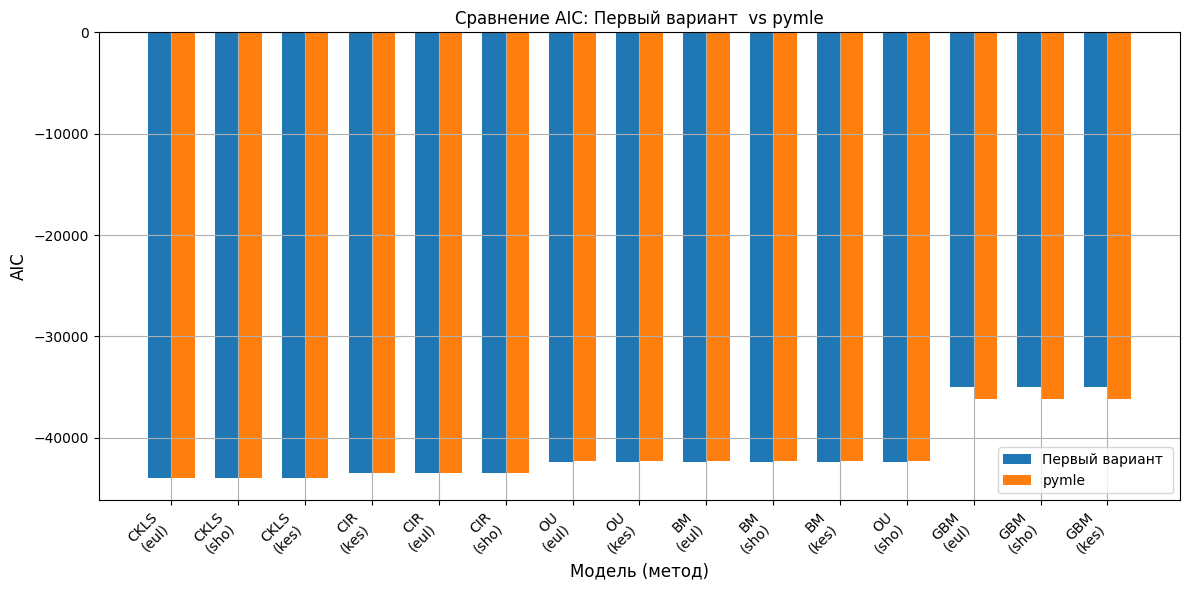

In [159]:
fig, ax = plt.subplots(figsize=(12, 6))

# Берём успешные оценки из pymle
pymle_success = pymle_df[pymle_df['AIC'].notna()].sort_values('AIC')

if len(pymle_success) > 0 and len(comparison_list) > 0:
    x = np.arange(len(pymle_success))
    width = 0.35

    # Получаем соответствующие AIC
    your_aics = []
    for _, row in pymle_success.iterrows():
        your_row = results_df[(results_df['Model'] == row['Model']) &
                               (results_df['Method'] == row['Method'])]
        if len(your_row) > 0:
            your_aics.append(your_row.iloc[0]['AIC'])
        else:
            your_aics.append(np.nan)

    ax.bar(x - width/2, your_aics, width, label='Оригинальный вариант ')
    ax.bar(x + width/2, pymle_success['AIC'].values, width, label='pymle')

    ax.set_xlabel('Модель (метод)', fontsize=12)
    ax.set_ylabel('AIC', fontsize=12)
    ax.set_title('Сравнение AIC: Оригинальный вариант  vs pymle')
    ax.set_xticks(x)
    ax.set_xticklabels([f"{row['Model']}\n({row['Method'][:3]})" for _, row in pymle_success.iterrows()],
                       rotation=45, ha='right')
    ax.legend()
    ax.grid()

    plt.tight_layout()
    plt.show()
else:
    print("\nНедостаточно данных для построения графика сравнения")



Обе реализации показывают хорошую согласованность, лучшая модель у обеих CKLS, оценки параметров близки

Был проведен анализ временного ряда процентных ставок (DGS10).


1.  Анализ исторических данных показал, что ряд процентных ставок является нестационарным и показывает значительную волатильность. Математическое ожидание близко к нулю (0.000135), что характерно для финансовых временных рядов. Стандартное отклонение (0.0162) подтверждает наличие заметной волатильности.

Тесты Jarque-Bera и Shapiro-Wilk отвергают гипотезу о нормальном распределении доходностей (p-value = 0.0). Это подтверждается на гистограмме (наличие "толстых хвостов") и QQ-plot (отклонение от прямой линии)

2.   Модели, учитывающие возврат к среднему (OU, CIR, CEV, CKLS), показали значительно лучшее качество, чем модели без возврата к среднему (BM, GBM)

Процесс не является случайным блужданием и стремится к некоторому долгосрочному равновесному уровню.

По критерию AIC лучшей оказалась модель CKLS

3.  Сравнение результатов оригинального кода и кода с использованием библиотеки pymle показало хорошую согласованность

Обе реализации выбрали лучшей моделью CKLS. Значения AIC для всех, успешно оцененных, моделей были близкими

4.  Симулированные траектории хорошо воспроизводят общий уровень и диапазон колебаний реальных ставок




